In [9]:
import pandas as pd
import numpy as np
from collections import Counter
import matplotlib.pyplot as plt
import seaborn as sns
import os
import pymupdf as fitz  # For PDF page counting

# Load the CSV file
file_path = 'Strict_regulations_for_Semantics/combined_all_filtered_constraints.csv'
df = pd.read_csv(file_path)

print(f"Original dataset shape: {df.shape}")
print("\nDataset columns:")
print(df.columns.tolist())
print("\nFirst few rows:")
print(df.head())

Original dataset shape: (2107, 25)

Dataset columns:
['model_name', 'document_number', 'type_of_wind_farm', 'chunk_number', 'document_id', 'constraint_type', 'requirement', 'scope', 'numerical_value', 'unit', 'source', 'related_domains', 'total_score', 'tfidf_mean_similarity', 'tfidf_max_similarity', 'jaccard_similarity', 'semantic_density', 'match_count', 'matched_keywords', 'has_numerical_values', 'extracted_numerical_value', 'scoring_method', 'threshold_level', 'relevance_category', 'priority_color']

First few rows:
       model_name       document_number type_of_wind_farm  chunk_number  \
0   deepseek-chat        NSOW-2023-0042          Offshore            83   
1     gpt-4o-mini  § 585.433, § 585.434          Offshore            81   
2  gemini-1.5-pro         page 56 of 98          Offshore            93   
3  gemini-2.5-pro        30 CFR 585.113          Offshore            27   
4   deepseek-chat         OWED-2023-001          Offshore            19   

   document_id constrai

Analyzing ALL 48 documents in the dataset...

COMPLETE DATASET ANALYSIS:
Total documents in dataset: 48
PDFs found: 48
PDFs not found: 0

STATISTICS FOR DOCUMENTS WITH PDFS FOUND (48 documents):
Total constraints: 2107
Total pages: 6502
Average pages per document: 135.5
Average constraints per document: 43.9
Average constraints per page: 0.57

PAGE COUNT DISTRIBUTION:
Min pages: 5
25th percentile: 21
Median pages: 80
75th percentile: 188
Max pages: 661

COMPREHENSIVE DOCUMENT RANKINGS:

1. RANKING BY CONSTRAINT COUNT (Most constraints first):
------------------------------------------------------------------------------------------------------------------------
Rank  Doc ID  Constraints  Pages   Const/Page  Model                Doc Number     
------------------------------------------------------------------------------------------------------------------------
1     26      322          177     1.82        gemini-1.5-pro       Page 17 of 93  
2     40      169          28      6.04  

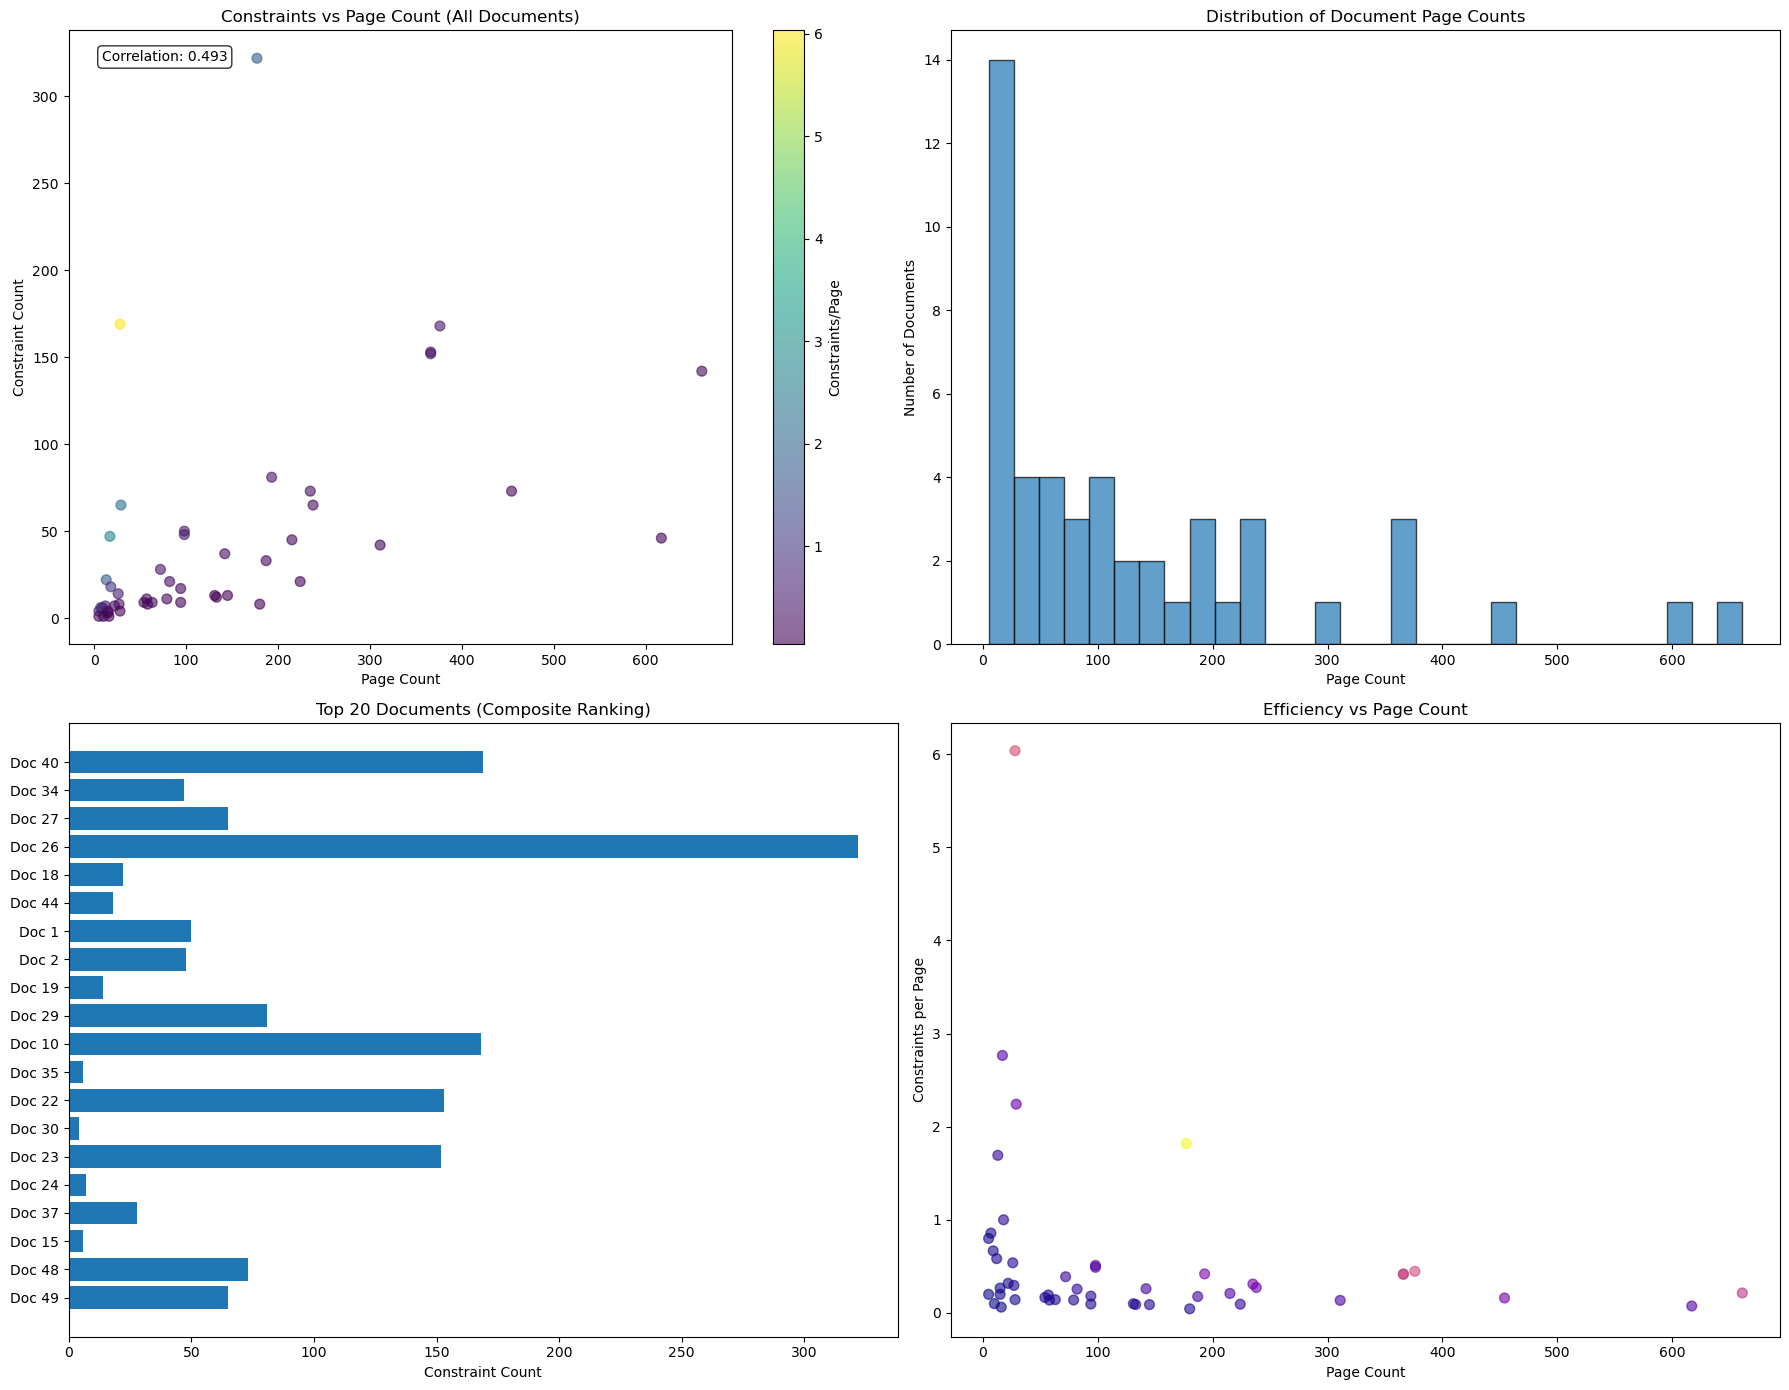


SAVING RESULTS:
Complete analysis saved to: Target_docs/complete_document_analysis_all.csv
Top 20 composite ranking data saved to: Target_docs/top_20_composite_ranking.csv
Summary statistics saved to: Target_docs/dataset_summary_statistics.csv

FINAL SUMMARY:
- Analyzed 48 documents total
- Found PDFs for 48 documents
- Top 20 composite ranking saved with 1498 constraints
- Best document: Doc 40 (169 constraints, 28 pages, 6.04 const/page)

FILTERING SELECTED DOCUMENTS: 40, 26, 34, 29

SELECTED DOCUMENTS ANALYSIS:
Found 4 out of 4 requested documents
------------------------------------------------------------------------------------------------------------------------

DOCUMENT 40:
  Constraint Count: 169
  Page Count: 28
  Constraints per Page: 6.036
  PDF Path: /Users/li/Library/CloudStorage/OneDrive-UniversityofMaryland/PhD research/Python/LLM/Documents/40.pdf
  Model Name: deepseek-chat
  Document Number: DOC-2023-001
  Type of Wind Farm: Offshore

DOCUMENT 26:
  Constraint Count

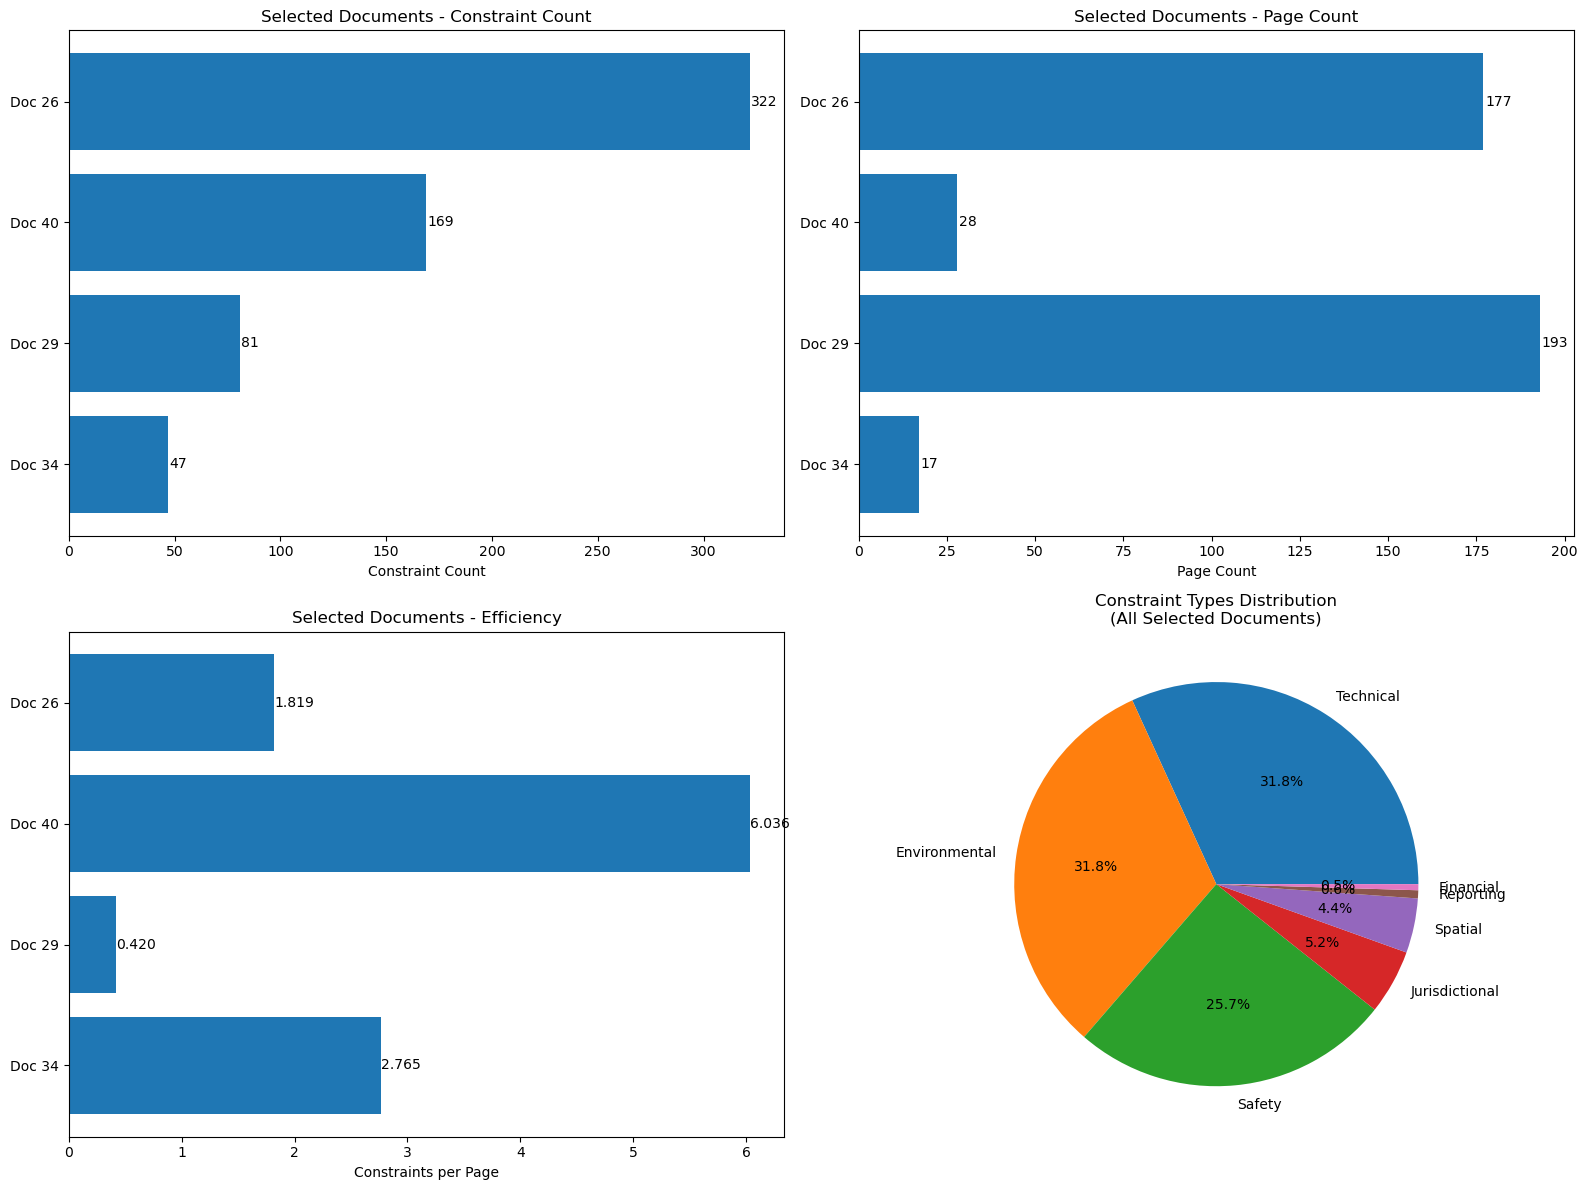

Visualization saved to: Target_docs/selected_documents_visualization.png

FILTERING COMPLETE!
Selected 4 documents with 619 total constraints


In [10]:
def get_pdf_page_count(document_id, documents_folder):
    """
    Get the page count of a PDF file based on document_id
    """
    # Try different file extensions and naming patterns
    possible_paths = [
        os.path.join(documents_folder, f"{document_id}.pdf"),
        os.path.join(documents_folder, f"Document_{document_id}.pdf"),
        os.path.join(documents_folder, f"doc_{document_id}.pdf"),
    ]
    
    for pdf_path in possible_paths:
        if os.path.exists(pdf_path):
            try:
                doc = fitz.open(pdf_path)
                page_count = len(doc)
                doc.close()
                return page_count, pdf_path
            except Exception as e:
                print(f"Error reading {pdf_path}: {e}")
                continue
    
    return None, None

# Documents folder path
documents_folder = '/Users/li/Library/CloudStorage/OneDrive-UniversityofMaryland/PhD research/Python/LLM/Documents'

# Analyze ALL documents in the dataset
document_counts = df['document_id'].value_counts()
all_documents = document_counts.index.tolist()

print(f"Analyzing ALL {len(all_documents)} documents in the dataset...")
print("="*70)

# Create detailed analysis with page counts for ALL documents
document_analysis = []
pdfs_found = 0
pdfs_not_found = 0

for i, doc_id in enumerate(all_documents, 1):
    constraint_count = document_counts[doc_id]
    page_count, pdf_path = get_pdf_page_count(doc_id, documents_folder)
    
    # Get additional document info from the dataset
    doc_info = df[df['document_id'] == doc_id].iloc[0]
    
    analysis_row = {
        'rank_by_constraints': i,
        'document_id': doc_id,
        'constraint_count': constraint_count,
        'page_count': page_count,
        'pdf_path': pdf_path,
        'document_number': doc_info.get('document_number', 'Not specified'),
        'model_name': doc_info.get('model_name', 'Not specified'),
        'type_of_wind_farm': doc_info.get('type_of_wind_farm', 'Not specified')
    }
    
    # Calculate efficiency (constraints per page)
    if page_count:
        analysis_row['constraints_per_page'] = constraint_count / page_count
        pdfs_found += 1
    else:
        analysis_row['constraints_per_page'] = None
        pdfs_not_found += 1
    
    document_analysis.append(analysis_row)

# Convert to DataFrame for easier analysis
doc_analysis_df = pd.DataFrame(document_analysis)

print(f"\nCOMPLETE DATASET ANALYSIS:")
print(f"{'='*70}")
print(f"Total documents in dataset: {len(doc_analysis_df)}")
print(f"PDFs found: {pdfs_found}")
print(f"PDFs not found: {pdfs_not_found}")

# Filter to only documents with found PDFs for efficiency analysis
found_docs = doc_analysis_df.dropna(subset=['page_count']).copy()

if not found_docs.empty:
    print(f"\nSTATISTICS FOR DOCUMENTS WITH PDFS FOUND ({len(found_docs)} documents):")
    print(f"Total constraints: {found_docs['constraint_count'].sum()}")
    print(f"Total pages: {found_docs['page_count'].sum():.0f}")
    print(f"Average pages per document: {found_docs['page_count'].mean():.1f}")
    print(f"Average constraints per document: {found_docs['constraint_count'].mean():.1f}")
    print(f"Average constraints per page: {found_docs['constraints_per_page'].mean():.2f}")
    
    print(f"\nPAGE COUNT DISTRIBUTION:")
    print(f"Min pages: {found_docs['page_count'].min():.0f}")
    print(f"25th percentile: {found_docs['page_count'].quantile(0.25):.0f}")
    print(f"Median pages: {found_docs['page_count'].median():.0f}")
    print(f"75th percentile: {found_docs['page_count'].quantile(0.75):.0f}")
    print(f"Max pages: {found_docs['page_count'].max():.0f}")
    
    # CREATE COMPREHENSIVE RANKINGS
    print(f"\n{'='*80}")
    print("COMPREHENSIVE DOCUMENT RANKINGS:")
    print(f"{'='*80}")
    
    # 1. Rank by constraint count (already done)
    constraints_ranked = found_docs.sort_values('constraint_count', ascending=False).reset_index(drop=True)
    constraints_ranked['rank_by_constraints'] = range(1, len(constraints_ranked) + 1)
    
    # 2. Rank by page count (shortest first)
    page_ranked = found_docs.sort_values('page_count', ascending=True).reset_index(drop=True)
    page_ranked['rank_by_pages'] = range(1, len(page_ranked) + 1)
    
    # 3. Rank by efficiency (constraints per page)
    efficiency_ranked = found_docs.sort_values('constraints_per_page', ascending=False).reset_index(drop=True)
    efficiency_ranked['rank_by_efficiency'] = range(1, len(efficiency_ranked) + 1)
    
    # 4. Calculate composite score (lower is better)
    # Normalize ranks to 0-1 scale and create weighted composite
    max_rank = len(found_docs)
    
    # Merge all rankings
    rankings_df = found_docs.copy()
    rankings_df = rankings_df.merge(
        constraints_ranked[['document_id', 'rank_by_constraints']], 
        on='document_id', 
        suffixes=('', '_new')
    )
    rankings_df = rankings_df.merge(
        page_ranked[['document_id', 'rank_by_pages']], 
        on='document_id'
    )
    rankings_df = rankings_df.merge(
        efficiency_ranked[['document_id', 'rank_by_efficiency']], 
        on='document_id'
    )
    
    # Calculate composite score (weighted average of normalized ranks)
    # Lower constraint rank (more constraints) = better
    # Lower page rank (fewer pages) = better  
    # Lower efficiency rank (higher efficiency) = better
    rankings_df['normalized_constraint_rank'] = rankings_df['rank_by_constraints_new'] / max_rank
    rankings_df['normalized_page_rank'] = rankings_df['rank_by_pages'] / max_rank  
    rankings_df['normalized_efficiency_rank'] = rankings_df['rank_by_efficiency'] / max_rank
    
    # Weighted composite (40% constraints, 30% efficiency, 30% page count)
    rankings_df['composite_score'] = (
        0.4 * rankings_df['normalized_constraint_rank'] + 
        0.3 * rankings_df['normalized_efficiency_rank'] + 
        0.3 * rankings_df['normalized_page_rank']
    )
    
    # Sort by composite score and add final ranking
    final_ranked = rankings_df.sort_values('composite_score', ascending=True).reset_index(drop=True)
    final_ranked['final_rank'] = range(1, len(final_ranked) + 1)
    
    # DISPLAY ALL RANKINGS
    print(f"\n1. RANKING BY CONSTRAINT COUNT (Most constraints first):")
    print("-" * 120)
    print(f"{'Rank':<5} {'Doc ID':<7} {'Constraints':<12} {'Pages':<7} {'Const/Page':<11} {'Model':<20} {'Doc Number':<15}")
    print("-" * 120)
    
    for idx, row in constraints_ranked.head(50).iterrows():  # Show top 50
        model_short = str(row['model_name'])[:19]
        doc_num_short = str(row['document_number'])[:14]
        print(f"{row['rank_by_constraints']:<5} {row['document_id']:<7} {row['constraint_count']:<12} "
              f"{row['page_count']:<7.0f} {row['constraints_per_page']:<11.2f} {model_short:<20} {doc_num_short:<15}")
    
    if len(constraints_ranked) > 50:
        print(f"... and {len(constraints_ranked) - 50} more documents")
    
    print(f"\n2. RANKING BY PAGE COUNT (Shortest documents first):")
    print("-" * 120)
    print(f"{'Rank':<5} {'Doc ID':<7} {'Pages':<7} {'Constraints':<12} {'Const/Page':<11} {'Model':<20} {'Doc Number':<15}")
    print("-" * 120)
    
    for idx, row in page_ranked.head(50).iterrows():  # Show top 50
        model_short = str(row['model_name'])[:19]
        doc_num_short = str(row['document_number'])[:14]
        print(f"{row['rank_by_pages']:<5} {row['document_id']:<7} {row['page_count']:<7.0f} "
              f"{row['constraint_count']:<12} {row['constraints_per_page']:<11.2f} {model_short:<20} {doc_num_short:<15}")
    
    if len(page_ranked) > 50:
        print(f"... and {len(page_ranked) - 50} more documents")
    
    print(f"\n3. RANKING BY EFFICIENCY (Highest constraints/page first):")
    print("-" * 120)
    print(f"{'Rank':<5} {'Doc ID':<7} {'Const/Page':<11} {'Constraints':<12} {'Pages':<7} {'Model':<20} {'Doc Number':<15}")
    print("-" * 120)
    
    for idx, row in efficiency_ranked.head(50).iterrows():  # Show top 50
        model_short = str(row['model_name'])[:19]
        doc_num_short = str(row['document_number'])[:14]
        print(f"{row['rank_by_efficiency']:<5} {row['document_id']:<7} {row['constraints_per_page']:<11.2f} "
              f"{row['constraint_count']:<12} {row['page_count']:<7.0f} {model_short:<20} {doc_num_short:<15}")
    
    if len(efficiency_ranked) > 50:
        print(f"... and {len(efficiency_ranked) - 50} more documents")
    
    print(f"\n4. FINAL COMPOSITE RANKING (Best overall balance):")
    print("-" * 140)
    print(f"{'Final':<6} {'Doc ID':<7} {'Score':<7} {'Constraints':<12} {'Pages':<7} {'Const/Page':<11} {'C-Rank':<7} {'P-Rank':<7} {'E-Rank':<7} {'Model':<15}")
    print("-" * 140)
    
    for idx, row in final_ranked.head(50).iterrows():  # Show top 50
        model_short = str(row['model_name'])[:14]
        print(f"{row['final_rank']:<6} {row['document_id']:<7} {row['composite_score']:<7.3f} "
              f"{row['constraint_count']:<12} {row['page_count']:<7.0f} {row['constraints_per_page']:<11.2f} "
              f"{row['rank_by_constraints_new']:<7} {row['rank_by_pages']:<7} {row['rank_by_efficiency']:<7} {model_short:<15}")
    
    if len(final_ranked) > 50:
        print(f"... and {len(final_ranked) - 50} more documents")
    
    # CREATE VISUALIZATIONS
    fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(18, 14))
    
    # 1. Scatter plot: Constraints vs Pages (all found docs)
    scatter = ax1.scatter(found_docs['page_count'], found_docs['constraint_count'], 
                         alpha=0.6, s=50, c=found_docs['constraints_per_page'], 
                         cmap='viridis')
    ax1.set_xlabel('Page Count')
    ax1.set_ylabel('Constraint Count')
    ax1.set_title('Constraints vs Page Count (All Documents)')
    plt.colorbar(scatter, ax=ax1, label='Constraints/Page')
    
    # Add correlation
    corr = found_docs['page_count'].corr(found_docs['constraint_count'])
    ax1.text(0.05, 0.95, f'Correlation: {corr:.3f}', transform=ax1.transAxes, 
            bbox=dict(boxstyle="round,pad=0.3", facecolor="white", alpha=0.8))
    
    # 2. Histogram: Page count distribution
    ax2.hist(found_docs['page_count'], bins=30, alpha=0.7, edgecolor='black')
    ax2.set_xlabel('Page Count')
    ax2.set_ylabel('Number of Documents')
    ax2.set_title('Distribution of Document Page Counts')
    
    # 3. Top 20 by composite score
    top_20_composite = final_ranked.head(20)
    bars = ax3.barh(range(len(top_20_composite)), top_20_composite['constraint_count'])
    ax3.set_yticks(range(len(top_20_composite)))
    ax3.set_yticklabels([f"Doc {doc_id}" for doc_id in top_20_composite['document_id']])
    ax3.set_xlabel('Constraint Count')
    ax3.set_title('Top 20 Documents (Composite Ranking)')
    ax3.invert_yaxis()
    
    # 4. Efficiency vs Page Count
    ax4.scatter(found_docs['page_count'], found_docs['constraints_per_page'], 
               alpha=0.6, s=50, c=found_docs['constraint_count'], cmap='plasma')
    ax4.set_xlabel('Page Count')
    ax4.set_ylabel('Constraints per Page')
    ax4.set_title('Efficiency vs Page Count')
    
    plt.tight_layout()
    plt.show()
    
    # SAVE RESULTS
    print(f"\n{'='*70}")
    print("SAVING RESULTS:")
    print(f"{'='*70}")
    
    # Save complete analysis
    complete_output_path = 'Target_docs/complete_document_analysis_all.csv'
    final_ranked.to_csv(complete_output_path, index=False)
    print(f"Complete analysis saved to: {complete_output_path}")
    
    # Save top 20 composite ranking
    top_20_docs = final_ranked.head(20)['document_id'].tolist()
    top_20_df = df[df['document_id'].isin(top_20_docs)]
    top_20_output_path = 'Target_docs/top_20_composite_ranking.csv'
    top_20_df.to_csv(top_20_output_path, index=False)
    print(f"Top 20 composite ranking data saved to: {top_20_output_path}")
    
    # Save summary statistics
    summary_stats = {
        'total_documents': len(doc_analysis_df),
        'pdfs_found': pdfs_found,
        'pdfs_not_found': pdfs_not_found,
        'total_constraints': found_docs['constraint_count'].sum(),
        'total_pages': found_docs['page_count'].sum(),
        'avg_pages_per_doc': found_docs['page_count'].mean(),
        'avg_constraints_per_doc': found_docs['constraint_count'].mean(),
        'avg_constraints_per_page': found_docs['constraints_per_page'].mean(),
        'correlation_pages_constraints': corr
    }
    
    summary_df = pd.DataFrame([summary_stats])
    summary_output_path = 'Target_docs/dataset_summary_statistics.csv'
    summary_df.to_csv(summary_output_path, index=False)
    print(f"Summary statistics saved to: {summary_output_path}")
    
    print(f"\nFINAL SUMMARY:")
    print(f"- Analyzed {len(doc_analysis_df)} documents total")
    print(f"- Found PDFs for {pdfs_found} documents")
    print(f"- Top 20 composite ranking saved with {top_20_df.shape[0]} constraints")
    print(f"- Best document: Doc {final_ranked.iloc[0]['document_id']} "
          f"({final_ranked.iloc[0]['constraint_count']} constraints, "
          f"{final_ranked.iloc[0]['page_count']:.0f} pages, "
          f"{final_ranked.iloc[0]['constraints_per_page']:.2f} const/page)")

else:
    print("No PDFs found for analysis.")
# FILTER AND DISPLAY SELECTED DOCUMENTS
print(f"\n{'='*80}")
print("FILTERING SELECTED DOCUMENTS: 40, 26, 34, 29")
print(f"{'='*80}")

selected_doc_ids = [40, 26, 34, 29]

# Filter the complete analysis for selected documents
selected_docs_analysis = doc_analysis_df[doc_analysis_df['document_id'].isin(selected_doc_ids)].copy()

if not selected_docs_analysis.empty:
    print(f"\nSELECTED DOCUMENTS ANALYSIS:")
    print(f"Found {len(selected_docs_analysis)} out of {len(selected_doc_ids)} requested documents")
    print("-" * 120)
    
    for doc_id in selected_doc_ids:
        doc_data = selected_docs_analysis[selected_docs_analysis['document_id'] == doc_id]
        if not doc_data.empty:
            row = doc_data.iloc[0]
            print(f"\nDOCUMENT {doc_id}:")
            print(f"  Constraint Count: {row['constraint_count']}")
            print(f"  Page Count: {row['page_count']:.0f}" if pd.notna(row['page_count']) else "  Page Count: PDF not found")
            print(f"  Constraints per Page: {row['constraints_per_page']:.3f}" if pd.notna(row['constraints_per_page']) else "  Constraints per Page: N/A")
            print(f"  PDF Path: {row['pdf_path']}" if pd.notna(row['pdf_path']) else "  PDF Path: Not found")
            print(f"  Model Name: {row['model_name']}")
            print(f"  Document Number: {row['document_number']}")
            print(f"  Type of Wind Farm: {row['type_of_wind_farm']}")
        else:
            print(f"\nDOCUMENT {doc_id}: NOT FOUND IN DATASET")
    
    # Get constraints data for selected documents
    selected_constraints = df[df['document_id'].isin(selected_doc_ids)].copy()
    
    print(f"\n{'='*80}")
    print("CONSTRAINT DETAILS FOR SELECTED DOCUMENTS:")
    print(f"{'='*80}")
    print(f"Total constraints found: {len(selected_constraints)}")
    
    for doc_id in selected_doc_ids:
        doc_constraints = selected_constraints[selected_constraints['document_id'] == doc_id]
        if not doc_constraints.empty:
            print(f"\n--- DOCUMENT {doc_id} CONSTRAINTS ({len(doc_constraints)} total) ---")
            
            # Group by constraint type
            constraint_types = doc_constraints['constraint_type'].value_counts()
            print(f"Constraint types breakdown:")
            for ctype, count in constraint_types.items():
                print(f"  - {ctype}: {count}")
            
            # Show top 10 constraints by score
            top_constraints = doc_constraints.nlargest(10, 'total_score')
            print(f"\nTop 10 constraints by relevance score:")
            for idx, (_, constraint) in enumerate(top_constraints.iterrows(), 1):
                print(f"  {idx}. [{constraint['constraint_type']}] {constraint['requirement'][:100]}...")
                print(f"     Score: {constraint['total_score']:.3f}, Value: {constraint['numerical_value']} {constraint['unit']}")
                print(f"     Source: {constraint['source']}")
        else:
            print(f"\n--- DOCUMENT {doc_id}: NO CONSTRAINTS FOUND ---")
    
    # Create summary statistics for selected documents
    print(f"\n{'='*80}")
    print("SUMMARY STATISTICS FOR SELECTED DOCUMENTS:")
    print(f"{'='*80}")
    
    valid_selected = selected_docs_analysis.dropna(subset=['page_count'])
    if not valid_selected.empty:
        print(f"Documents with PDFs found: {len(valid_selected)}")
        print(f"Total constraints: {valid_selected['constraint_count'].sum()}")
        print(f"Total pages: {valid_selected['page_count'].sum():.0f}")
        print(f"Average constraints per document: {valid_selected['constraint_count'].mean():.1f}")
        print(f"Average pages per document: {valid_selected['page_count'].mean():.1f}")
        print(f"Average constraints per page: {valid_selected['constraints_per_page'].mean():.3f}")
        
        print(f"\nDocument ranking by constraint count:")
        constraint_ranking = valid_selected.sort_values('constraint_count', ascending=False)
        for idx, (_, row) in enumerate(constraint_ranking.iterrows(), 1):
            print(f"  {idx}. Doc {row['document_id']}: {row['constraint_count']} constraints, {row['page_count']:.0f} pages")
    else:
        print("No PDFs found for selected documents")
    
    # Save filtered results
    print(f"\n{'='*80}")
    print("SAVING FILTERED RESULTS:")
    print(f"{'='*80}")
    
    # Create Target_docs directory if it doesn't exist
    import os
    os.makedirs('Target_docs', exist_ok=True)
    
    # Save selected documents analysis
    selected_output_path = 'Target_docs/selected_documents_analysis.csv'
    selected_docs_analysis.to_csv(selected_output_path, index=False)
    print(f"Selected documents analysis saved to: {selected_output_path}")
    
    # Save all constraints for selected documents
    selected_constraints_path = 'Target_docs/selected_documents_constraints.csv'
    selected_constraints.to_csv(selected_constraints_path, index=False)
    print(f"All constraints for selected documents saved to: {selected_constraints_path}")
    
    # Save detailed breakdown by document
    with open('Target_docs/selected_documents_detailed_report.txt', 'w') as f:
        f.write("DETAILED ANALYSIS REPORT FOR SELECTED DOCUMENTS\n")
        f.write("=" * 60 + "\n\n")
        
        for doc_id in selected_doc_ids:
            doc_data = selected_docs_analysis[selected_docs_analysis['document_id'] == doc_id]
            doc_constraints = selected_constraints[selected_constraints['document_id'] == doc_id]
            
            f.write(f"DOCUMENT {doc_id}\n")
            f.write("-" * 30 + "\n")
            
            if not doc_data.empty:
                row = doc_data.iloc[0]
                f.write(f"Constraint Count: {row['constraint_count']}\n")
                f.write(f"Page Count: {row['page_count']:.0f}\n" if pd.notna(row['page_count']) else "Page Count: PDF not found\n")
                f.write(f"Constraints per Page: {row['constraints_per_page']:.3f}\n" if pd.notna(row['constraints_per_page']) else "Constraints per Page: N/A\n")
                f.write(f"Model Name: {row['model_name']}\n")
                f.write(f"Document Number: {row['document_number']}\n")
                f.write(f"Type of Wind Farm: {row['type_of_wind_farm']}\n")
                f.write(f"PDF Path: {row['pdf_path']}\n" if pd.notna(row['pdf_path']) else "PDF Path: Not found\n")
            else:
                f.write("Document not found in dataset\n")
            
            if not doc_constraints.empty:
                f.write(f"\nConstraint Types ({len(doc_constraints)} total):\n")
                constraint_types = doc_constraints['constraint_type'].value_counts()
                for ctype, count in constraint_types.items():
                    f.write(f"  - {ctype}: {count}\n")
                
                f.write("\nTop 10 Constraints by Relevance Score:\n")
                top_constraints = doc_constraints.nlargest(10, 'total_score')
                for idx, (_, constraint) in enumerate(top_constraints.iterrows(), 1):
                    f.write(f"  {idx}. [{constraint['constraint_type']}] {constraint['requirement']}\n")
                    f.write(f"     Score: {constraint['total_score']:.3f}, Value: {constraint['numerical_value']} {constraint['unit']}\n")
                    f.write(f"     Source: {constraint['source']}\n")
                    f.write(f"     Scope: {constraint['scope']}\n\n")
            else:
                f.write("\nNo constraints found for this document\n")
            
            f.write("\n" + "=" * 60 + "\n\n")
    
    print(f"Detailed report saved to: Target_docs/selected_documents_detailed_report.txt")
    
    # Create visualization for selected documents
    if len(valid_selected) > 0:
        fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(16, 12))
        
        # 1. Bar chart of constraint counts
        valid_selected_sorted = valid_selected.sort_values('constraint_count', ascending=True)
        bars1 = ax1.barh(range(len(valid_selected_sorted)), valid_selected_sorted['constraint_count'])
        ax1.set_yticks(range(len(valid_selected_sorted)))
        ax1.set_yticklabels([f"Doc {doc_id}" for doc_id in valid_selected_sorted['document_id']])
        ax1.set_xlabel('Constraint Count')
        ax1.set_title('Selected Documents - Constraint Count')
        
        # Add value labels on bars
        for i, bar in enumerate(bars1):
            width = bar.get_width()
            ax1.text(width + 0.5, bar.get_y() + bar.get_height()/2, 
                    f'{int(width)}', ha='left', va='center')
        
        # 2. Bar chart of page counts
        bars2 = ax2.barh(range(len(valid_selected_sorted)), valid_selected_sorted['page_count'])
        ax2.set_yticks(range(len(valid_selected_sorted)))
        ax2.set_yticklabels([f"Doc {doc_id}" for doc_id in valid_selected_sorted['document_id']])
        ax2.set_xlabel('Page Count')
        ax2.set_title('Selected Documents - Page Count')
        
        # Add value labels on bars
        for i, bar in enumerate(bars2):
            width = bar.get_width()
            ax2.text(width + 0.5, bar.get_y() + bar.get_height()/2, 
                    f'{int(width)}', ha='left', va='center')
        
        # 3. Efficiency comparison
        bars3 = ax3.barh(range(len(valid_selected_sorted)), valid_selected_sorted['constraints_per_page'])
        ax3.set_yticks(range(len(valid_selected_sorted)))
        ax3.set_yticklabels([f"Doc {doc_id}" for doc_id in valid_selected_sorted['document_id']])
        ax3.set_xlabel('Constraints per Page')
        ax3.set_title('Selected Documents - Efficiency')
        
        # Add value labels on bars
        for i, bar in enumerate(bars3):
            width = bar.get_width()
            ax3.text(width + 0.001, bar.get_y() + bar.get_height()/2, 
                    f'{width:.3f}', ha='left', va='center')
        
        # 4. Constraint type breakdown for all selected documents
        all_constraint_types = selected_constraints['constraint_type'].value_counts()
        ax4.pie(all_constraint_types.values, labels=all_constraint_types.index, autopct='%1.1f%%')
        ax4.set_title('Constraint Types Distribution\n(All Selected Documents)')
        
        plt.tight_layout()
        plt.savefig('Target_docs/selected_documents_visualization.png', dpi=300, bbox_inches='tight')
        plt.show()
        
        print(f"Visualization saved to: Target_docs/selected_documents_visualization.png")
    
    print(f"\nFILTERING COMPLETE!")
    print(f"Selected {len(selected_doc_ids)} documents with {len(selected_constraints)} total constraints")
    
else:
    print("No data found for the selected documents")